<a href="https://colab.research.google.com/github/tdraths/hurling-match-data/blob/main/notebooks/01_eda_2025_AIF_COR_TIP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 2025 All-Ireland Hurling Final - Match Analysis
# Cork vs Tipperary
# Notebook: 01_eda_2025_AIF_COR_TIP.ipynb

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# Set up path header
BASE = 'https://raw.githubusercontent.com/tdraths/hurling-match-data/refs/heads/main/'

In [ ]:
# Color palette
C_COR = '#e05050' # Cork - red
C_TIP = '#003DA5' # Tipperary - blue
C_GRASS = '#2d5a2d'
C_LIME = '#c6f135'
C_GOLD = '#f5c842'
C_MUTED = '#888888'

In [ ]:
# Loading data
po = pd.read_csv(BASE + "data/processed/puckouts/puckouts_2025_AIF_COR_TIP.csv")
fr = pd.read_csv(BASE + "data/processed/frees/frees_2025_AIF_COR_TIP.csv")

In [ ]:
# Derived Columns
po['retained_bool'] = po['retained'] == 'yes'
po['is_cork'] = po['pucking_team'] == 'Cork'

fr['scored'] = fr['outcome'].isin(['point', 'goal'])
fr['possession'] = fr['outcome'].isin(['retained', 'point', 'goal'])
fr['is_cork'] = fr['shooting_team'] == 'Cork'

print(f"Puckouts loaded: {len(po)}")
print(f"Frees/65s loaded: {len(fr)}")
print(f"\nMatch: {po['match'].iloc[0]} | Date: {po['date'].iloc[0]}")
print(f"\nPuckouts by team:")
print(po['pucking_team'].value_counts().to_string())
print(f"\nOverall retention rate: {po['retained_bool'].mean()*100:.1f}%")

Puckouts loaded: 72
Frees/65s loaded: 32

Match: 2025_AIF_COR_TIP | Date: 2025-07-20

Puckouts by team:
pucking_team
Cork         44
Tipperary    28

Overall retention rate: 68.1%


In [ ]:
# Functions to draw a hurling pitch

PO_ZONES = {
    'AL': (0,0), 'AC': (0,1), 'AR': (0,2),
    'ML': (1,0), 'MC': (1,1), 'MR': (1,2),
    'DL': (2,0), 'DC': (2,1), 'DR': (2,2),
}

FR_ZONES = {
    'F1L': (0,0), 'F1CL': (0,1), 'F1CR': (0,2), 'F1R': (0,3),
    'F2L': (1,0), 'F2CL': (1,1), 'F2CR': (1,2), 'F2R': (1,3),
    'F3L': (2,0), 'F3CL': (2,1), 'F3CR': (2,2), 'F3R': (2,3),
    'F4L': (3,0), 'F4CL': (3,1), 'F4CR': (3,2), 'F4R': (3,3),
    'F5L': (4,0), 'F5CL': (4,1), 'F5CR': (4,2), 'F5R': (4,3),
}

FR_ZONE_LABELS = {
    'F1L':'L\n<13m','F1CL':'CL\n<13m','F1CR':'CR\n<13m','F1R':'R\n<13m',
    'F2L':'L\n13-21','F2CL':'CL\n13-21','F2CR':'CR\n13-21','F2R':'R\n13-21',
    'F3L':'L\n21-45','F3CL':'CL\n21-45','F3CR':'CR\n21-45','F3R':'R\n21-45',
    'F4L':'L\n45-65','F4CL':'CL\n45-65','F4CR':'CR\n45-65','F4R':'R\n45-65',
    'F5L':'L\n>65m','F5CL':'CL\n>65m','F5CR':'CR\n>65m','F5R':'R\n>65m',
}

rg_cmap = LinearSegmentedColormap.from_list('rg', ['#e05050', '#f5c842', '#5ab55a'])

def draw_po_pitch(ax, values_dict, cmap, title='', show_pct=True, alpha=0.85):
    ax.set_facecolor(C_GRASS)
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)
    ax.set_aspect('equal')
    for zone, (row, col) in PO_ZONES.items():
        val = values_dict.get(zone, np.nan)
        color = cmap(val) if not np.isnan(val) else '#333333'
        ax.add_patch(patches.Rectangle(
            (col, 2 - row), 1, 1,
            facecolor=color, alpha=alpha,
            edgecolor='#1a3a1a', linewidth=1.5
        ))
        label = f"{zone}\n{val*100:.0f}%" if show_pct and not np.isnan(val) else zone
        ax.text(
            col + 0.5, 2 - row + 0.5,   # <-- row not r
            label,
            ha='center', va='center',
            fontsize=8, fontweight='bold', color='white'
        )
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.text(0.02, -0.06, '← Opp Goal', transform=ax.transAxes,
            fontsize=7, color=C_MUTED)
    ax.text(0.98, -0.06, 'Own Goal →', transform=ax.transAxes,
            fontsize=7, color=C_MUTED, ha='right')

def draw_fr_pitch(ax, values_dict, cmap, title='', label_fn=None, alpha=0.85):
    ax.set_facecolor(C_GRASS)
    ax.set_xlim(0,4); ax.set_ylim(0,5)
    ax.set_aspect('equal')
    for zone,(row,col) in FR_ZONES.items():
        val = values_dict.get(zone, np.nan)
        color = cmap(val) if not np.isnan(val) else '#333333'
        ax.add_patch(patches.Rectangle((col,4-row),1,1,facecolor=color,alpha=alpha,edgecolor='#1a3a1a',linewidth=1))
        lbl = label_fn(zone,val) if label_fn else (FR_ZONE_LABELS.get(zone,zone) + (f"\n{val*100:.0f}%" if not np.isnan(val) else ''))
        ax.text(col+0.5,4-row+0.5,lbl,ha='center',va='center',fontsize=6.5,color='white',fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title,fontsize=11,fontweight='bold',pad=8)
    ax.text(0.5,-0.06,'← Scoring End',transform=ax.transAxes,fontsize=7,color=C_MUTED,ha='center')

def style_ax(ax):
    ax.set_facecolor('#0f1f0f')
    ax.tick_params(colors='white')
    ax.spines[['top','right','left','bottom']].set_color('#2a4a2a')

print("Helpers ready.")

Helpers ready.


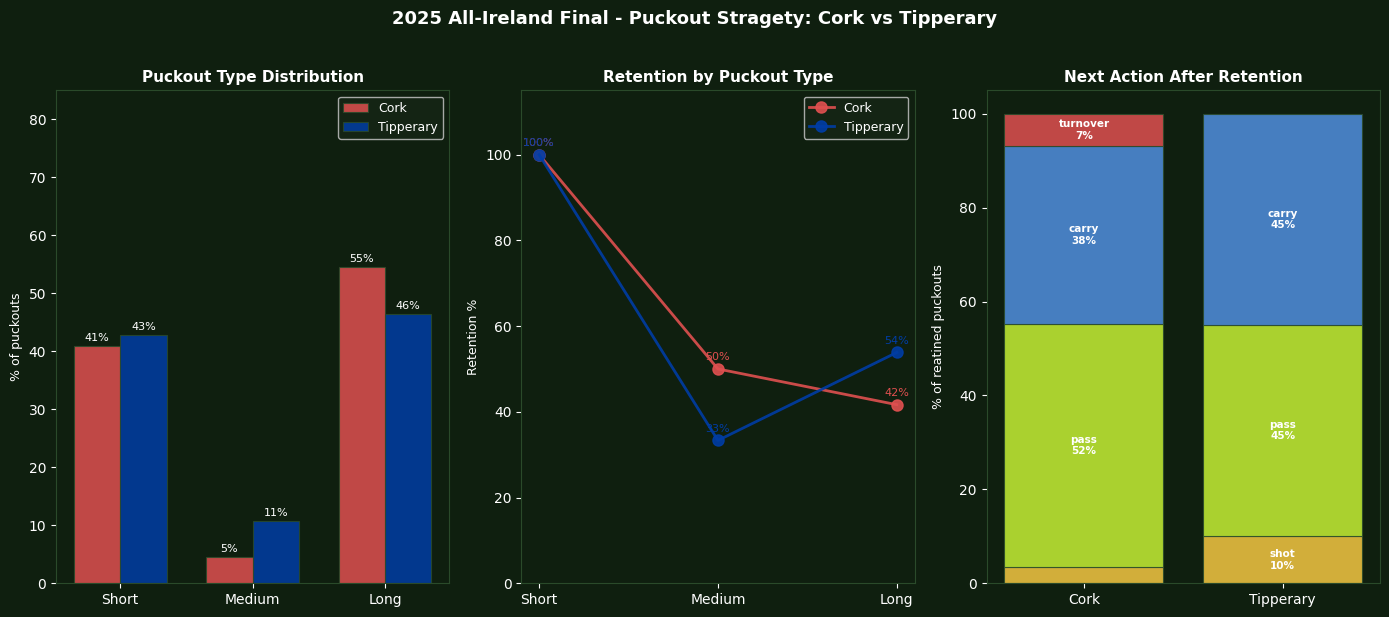


=== PUCKOUT TYPE SUMMARY ===
                     count retention
pucking_team type                   
Cork         long       24       42%
             medium      2       50%
             short      18      100%
Tipperary    long       13       54%
             medium      3       33%
             short      12      100%


In [ ]:
# Puckout Strategy Comparison

fig, axes = plt.subplots(1,3,figsize=(14,6))
fig.patch.set_facecolor('#0f1f0f')

teams = ['Cork', 'Tipperary']
colors = [C_COR, C_TIP]
types = ['short', 'medium', 'long']

# Panel 1: Type Distribution
ax = axes[0]
x = np.arange(len(types))
w = 0.35
for i,(team,col) in enumerate(zip(teams, colors)):
    sub = po[po['pucking_team']==team]
    pcts = [len(sub[sub['type']==t])/len(sub)*100 for t in types]
    bars = ax.bar(x+i*w, pcts, w, label=team, color=col, alpha=0.85, edgecolor='#2a4a2a', linewidth=0.8)
    for bar,pct in zip(bars,pcts):
        if pct>3:
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+0.5,f'{pct:.0f}%',
                    ha='center',va='bottom',fontsize=8,color='white')
ax.set_xticks(x+w/2); ax.set_xticklabels([t.title() for t in types],color='white', fontsize=10)
ax.set_ylabel('% of puckouts',color='white',fontsize=9)
ax.set_title('Puckout Type Distribution', color='white', fontsize=11, fontweight='bold')
ax.legend(facecolor='#162616', labelcolor='white', fontsize=9); ax.set_ylim(0,85)
style_ax(ax)

# Panel 2: Retention by type
ax = axes[1]
for team, col in zip(teams,colors):
    sub = po[po['pucking_team']==team]
    xs, ys = [], []
    for t in types:
        s = sub[sub['type']==t]
        if len(s)>=2:
            xs.append(t.title()); ys.append(s['retained_bool'].mean()*100)
    ax.plot(xs, ys, 'o-', color=col, linewidth=2, markersize=8, label=team, alpha=0.9)
    for x_,y_ in zip(xs,ys):
        ax.text(x_,y_+2, f'{y_:.0f}%', ha='center', fontsize=8, color=col)
ax.set_ylabel('Retention %', color='white', fontsize=9)
ax.set_title('Retention by Puckout Type', color='white', fontsize=11, fontweight='bold')
ax.legend(facecolor='#162616', labelcolor='white', fontsize=9); ax.set_ylim(0,115)
style_ax(ax)

# Panel 3: Next action breakdown (retained puckouts only)
ax = axes[2]
actions = ['shot', 'pass', 'carry', 'foul-won', 'turnover', 'unknown']
act_colors = ['#f5c842','#c6f135','#5090e0','#e08830','#e05050','#555555']
ret_po = po[po['retained']=='yes']
for i,(team,col) in enumerate(zip(teams,colors)):
    sub = ret_po[ret_po['pucking_team'] == team]
    total = len(sub)
    bottom = 0
    for action,act_color in zip(actions,act_colors):
        cnt = len(sub[sub['next_action']==action])
        if cnt>0:
            pct = cnt/total*100
            ax.bar(i, pct, bottom=bottom, color=act_color, edgecolor='#2a4a2a', linewidth=0.8, alpha=0.85)
            if pct>5:
                ax.text(i, bottom+pct/2, f'{action}\n{pct:.0f}%', ha='center', va='center', fontsize=7.5, color='white', fontweight='bold')
            bottom+=pct
ax.set_xticks([0,1]); ax.set_xticklabels(teams, color='white', fontsize=10)
ax.set_ylabel('% of reatined puckouts', color='white', fontsize=9)
ax.set_title('Next Action After Retention', color='white', fontsize=11, fontweight='bold')
style_ax(ax)

plt.suptitle('2025 All-Ireland Final - Puckout Stragety: Cork vs Tipperary', color='white', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('q1_puckout_strategy.png', dpi=150, bbox_inches='tight', facecolor='#0f1f0f')

plt.show()

print("\n=== PUCKOUT TYPE SUMMARY ===")
print(po.groupby(['pucking_team', 'type']).agg(count=('id', 'count'), retention=('retained_bool', lambda x:f"{x.mean()*100:.0f}%")).to_string())

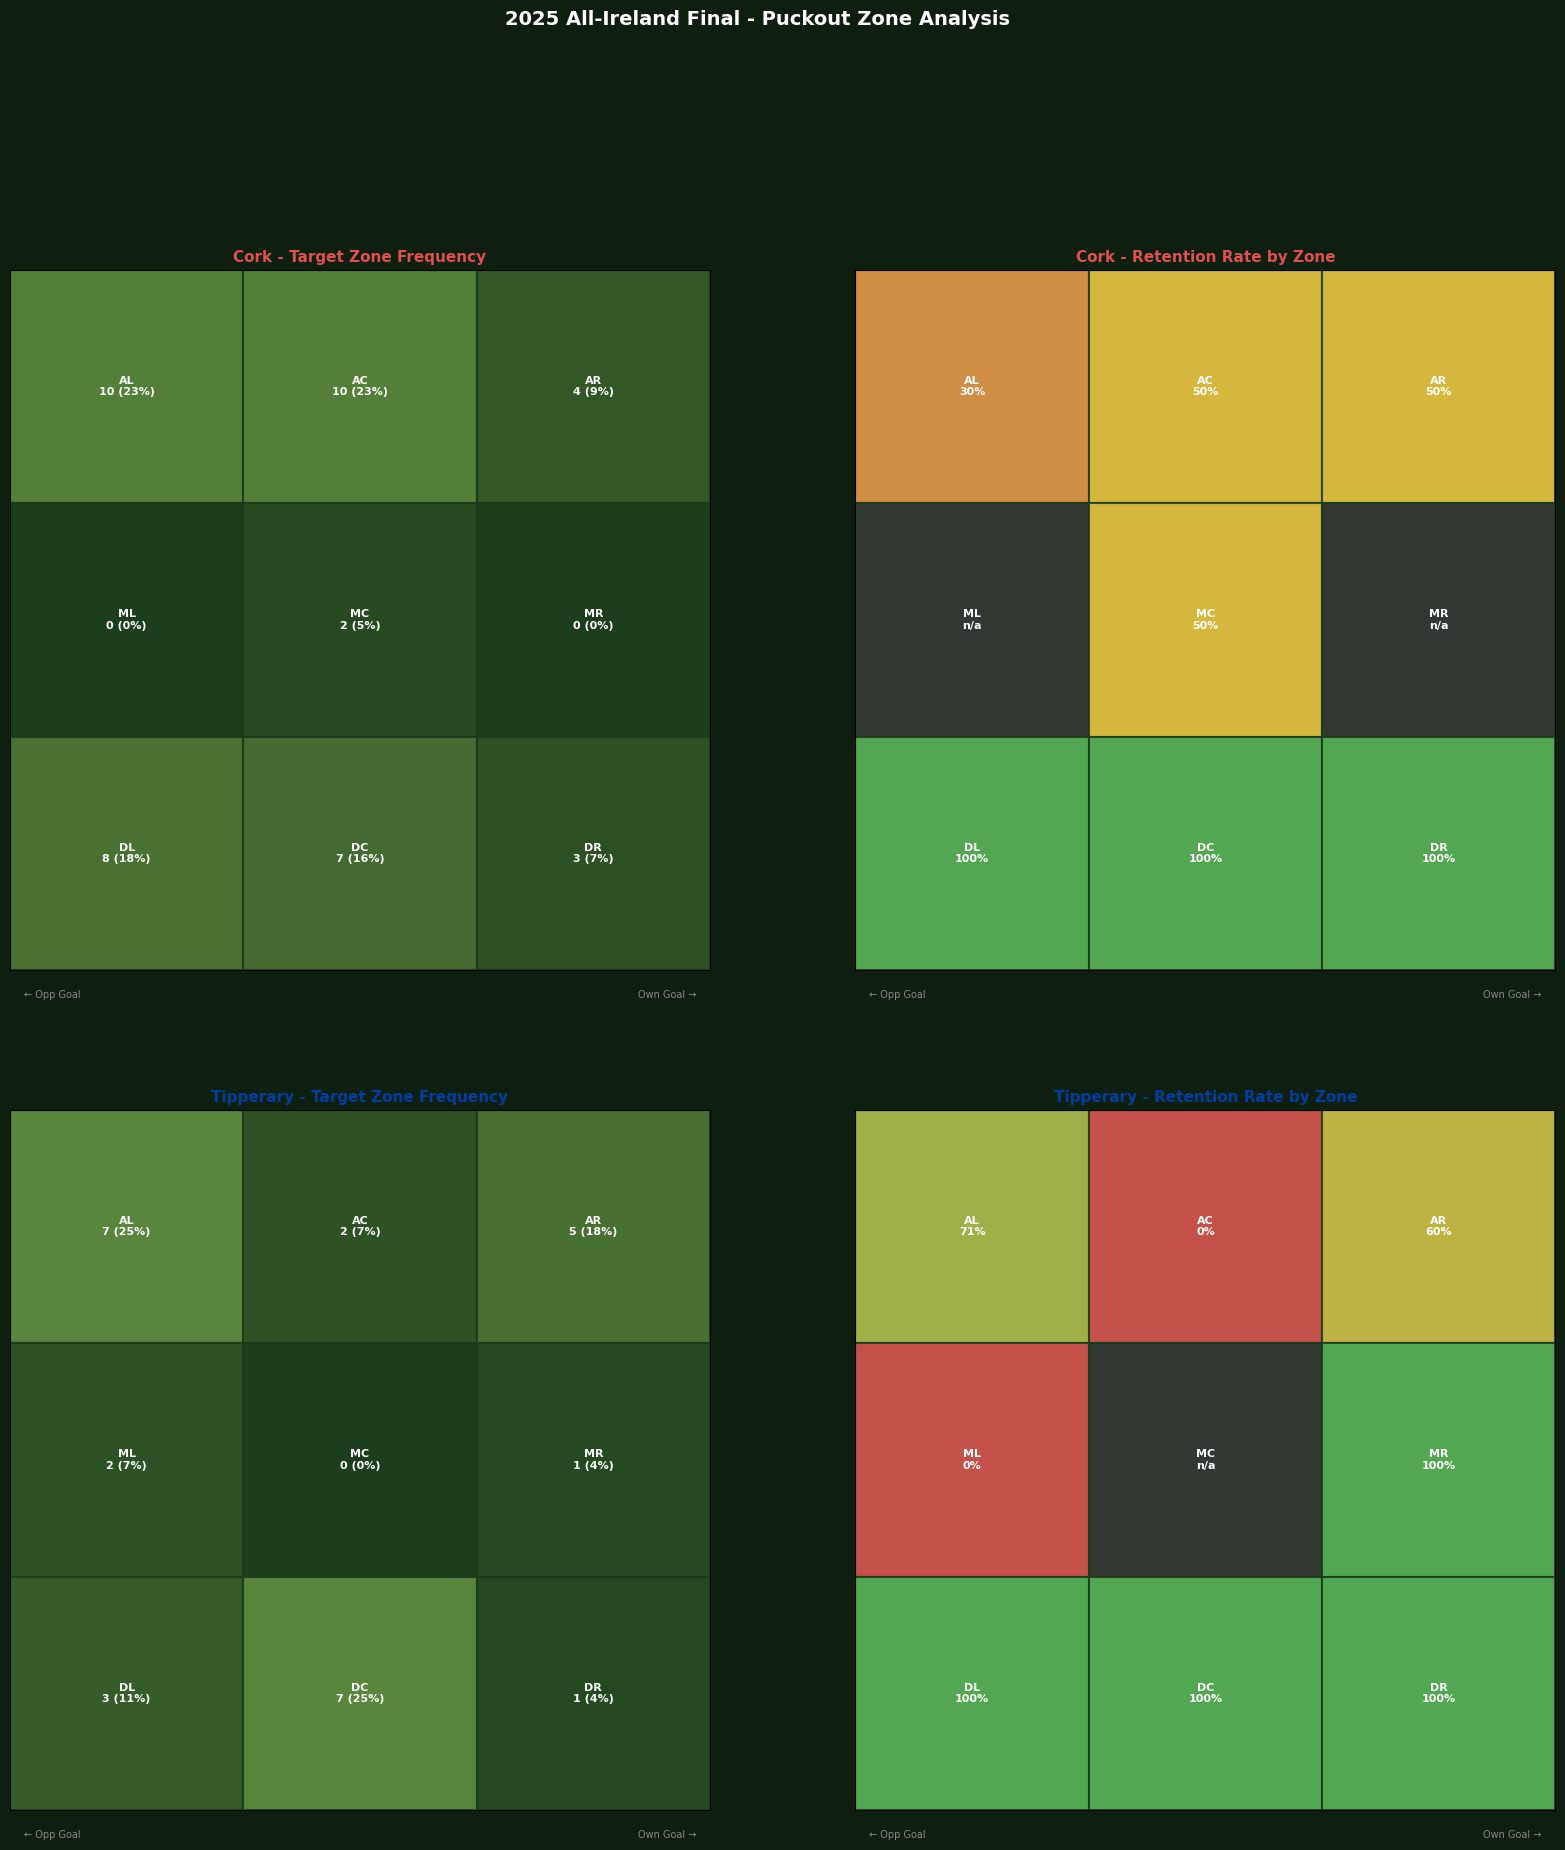


=== ZONE RETENTION BY TEAM ===
                          attempts  retained   pct
pucking_team target_zone                          
Cork         AC                 10         5   50%
             AL                 10         3   30%
             AR                  4         2   50%
             DC                  7         7  100%
             DL                  8         8  100%
             DR                  3         3  100%
             MC                  2         1   50%
Tipperary    AC                  2         0    0%
             AL                  7         5   71%
             AR                  5         3   60%
             DC                  7         7  100%
             DL                  3         3  100%
             DR                  1         1  100%
             ML                  2         0    0%
             MR                  1         1  100%


In [ ]:
#Q2: Zone Analysis

fig, axes = plt.subplots(2, 2, figsize=(20, 20))
fig.patch.set_facecolor('#0f1f0f')

for row_i, team in enumerate(['Cork', 'Tipperary']):
    sub = po[po['pucking_team']==team]
    col_t = C_COR if team=='Cork' else C_TIP
    total = len(sub)
    zone_counts = sub['target_zone'].value_counts()

    # Frequency map
    freq_cmap = LinearSegmentedColormap.from_list('freq', ['#1a3a1a', '#a8e063', col_t])
    freq_dict = {z: zone_counts.get(z,0)/total for z in PO_ZONES}
    ax = axes[row_i][0]
    ax.set_facecolor(C_GRASS); ax.set_xlim(0,3); ax.set_ylim(0,3); ax.set_aspect('equal')
    for zone, (row, col) in PO_ZONES.items():
        val = freq_dict.get(zone,0)
        ax.add_patch(patches.Rectangle((col,2-row),1,1, facecolor=freq_cmap(val), alpha=0.85, edgecolor='#1a3a1a', linewidth=1.5))
        cnt = zone_counts.get(zone,0)
        ax.text(col+0.5,2-row+0.5,f"{zone}\n{cnt} ({val*100:.0f}%)", ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'{team} - Target Zone Frequency', fontsize=11, fontweight='bold', color=col_t)
    ax.text(0.02,-0.04,'← Opp Goal',transform=ax.transAxes,fontsize=7,color=C_MUTED)
    ax.text(0.98,-0.04,'Own Goal →',transform=ax.transAxes,fontsize=7,color=C_MUTED,ha='right')

    # Retention rate map
    zone_ret = {}
    for zone in PO_ZONES:
        s = sub[sub['target_zone']==zone]
        zone_ret[zone] = s['retained_bool'].mean() if len(s)>0 else np.nan
    ax = axes[row_i][1]
    ax.set_facecolor(C_GRASS); ax.set_xlim(0,3); ax.set_ylim(0,3); ax.set_aspect('equal')
    for zone,(row,col) in PO_ZONES.items():
        val = zone_ret.get(zone,np.nan)
        color = rg_cmap(val) if not np.isnan(val) else '#333333'
        ax.add_patch(patches.Rectangle((col,2-row),1,1, facecolor=color, alpha=0.85, edgecolor='#1a3a1a', linewidth=1.5))
        lbl = f"{zone}\n{val*100:.0f}%" if not np.isnan(val) else f"{zone}\nn/a"
        ax.text(col+0.5,2-row+0.5,lbl,ha='center',va='center',
                fontsize=8,color='white',fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'{team} - Retention Rate by Zone',fontsize=11,fontweight='bold',color=col_t)
    ax.text(0.02,-0.04,'← Opp Goal',transform=ax.transAxes,fontsize=7,color=C_MUTED)
    ax.text(0.98,-0.04,'Own Goal →',transform=ax.transAxes,fontsize=7,color=C_MUTED,ha='right')

plt.suptitle('2025 All-Ireland Final - Puckout Zone Analysis', color='white', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('q2_zone_analysis.png',dpi=150,bbox_inches='tight',facecolor='#0f1f0f')
plt.show()

print("\n=== ZONE RETENTION BY TEAM ===")
print(po.groupby(['pucking_team','target_zone']).agg(
    attempts=('id','count'),
    retained=('retained_bool','sum'),
    pct=('retained_bool',lambda x:f"{x.mean()*100:.0f}%")).to_string())


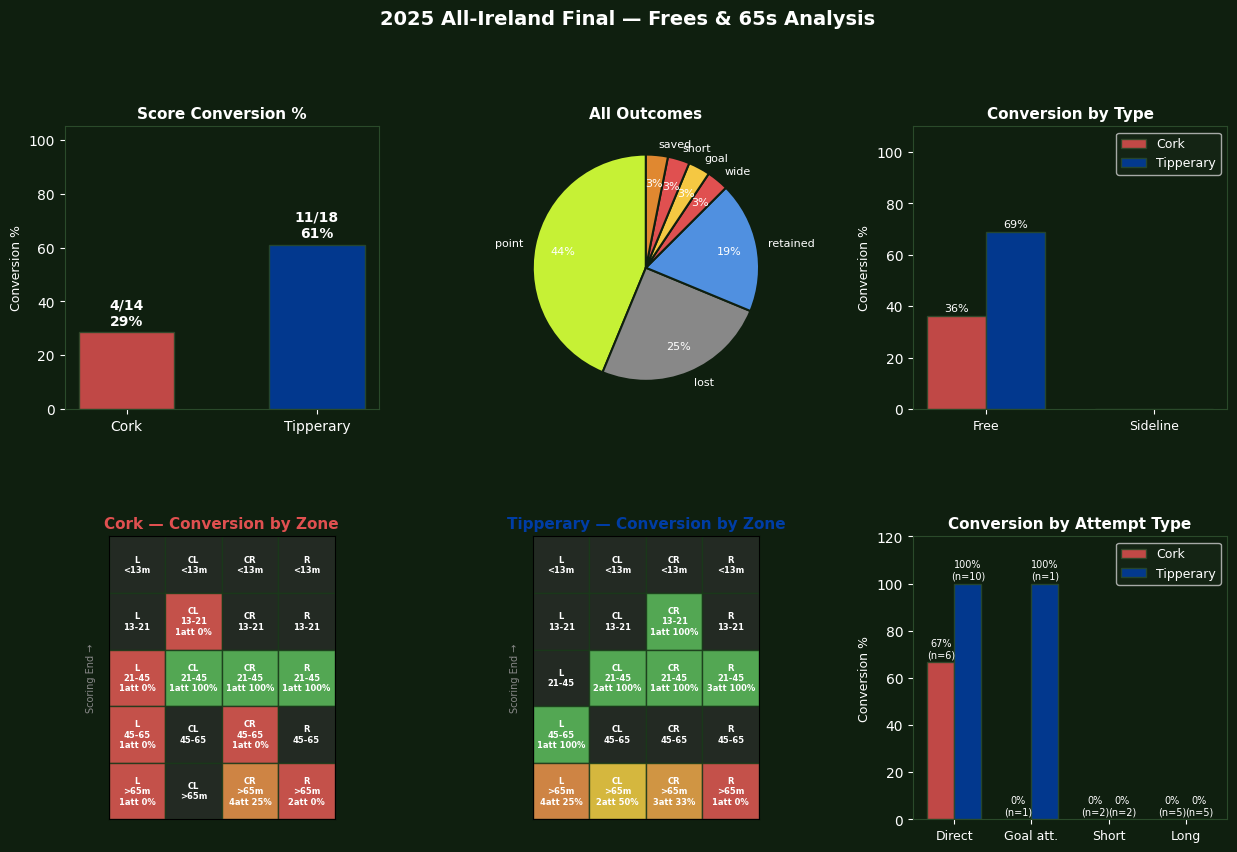


=== FREES SUMMARY ===
                              attempts  scored conversion
shooting_team set_piece_type                             
Cork          free                  11       4        36%
              sideline               3       0         0%
Tipperary     free                  16      11        69%
              sideline               2       0         0%


In [ ]:
# Q3: Frees & 65s Analysis

fig = plt.figure(figsize=(15,9))
fig.patch.set_facecolor('#0f1f0f')
gs_layout = gridspec.GridSpec(2,3,figure=fig,hspace=0.45,wspace=0.35)

# P1: Overall conversion
ax1 = fig.add_subplot(gs_layout[0,0])
for i,(team,col) in enumerate(zip(teams,colors)):
    sub   = fr[fr['shooting_team']==team]
    total = len(sub); scored = sub['scored'].sum()
    pct   = scored/total*100 if total>0 else 0
    ax1.bar(i,pct,color=col,alpha=0.85,edgecolor='#2a4a2a',width=0.5)
    ax1.text(i,pct+1.5,f'{scored}/{total}\n{pct:.0f}%',
             ha='center',va='bottom',fontsize=10,color='white',fontweight='bold')
ax1.set_xticks([0,1]); ax1.set_xticklabels(teams,color='white',fontsize=10)
ax1.set_ylabel('Conversion %',color='white',fontsize=9)
ax1.set_title('Score Conversion %',color='white',fontsize=11,fontweight='bold')
ax1.set_ylim(0,105); style_ax(ax1)

# P2: Outcome pie
ax2 = fig.add_subplot(gs_layout[0,1])
out_cols_map = {'point':'#c6f135','goal':'#f5c842','wide':'#e05050',
                'short':'#e05050','saved':'#e08830','cleared':'#e08830',
                'retained':'#5090e0','lost':'#888888'}
outcomes = fr['outcome'].value_counts()
ax2.pie(outcomes.values,labels=outcomes.index,
        colors=[out_cols_map.get(o,'#555555') for o in outcomes.index],
        autopct='%1.0f%%',pctdistance=0.75,startangle=90,
        wedgeprops={'edgecolor':'#0f1f0f','linewidth':1.5})
for t in ax2.texts: t.set_color('white'); t.set_fontsize(8)
ax2.set_title('All Outcomes',color='white',fontsize=11,fontweight='bold')
ax2.set_facecolor('#0f1f0f')

# P3: Conversion by set piece type
ax3 = fig.add_subplot(gs_layout[0,2])
spt_order = fr['set_piece_type'].value_counts().index.tolist()
for i,(team,col) in enumerate(zip(teams,colors)):
    sub   = fr[fr['shooting_team']==team]
    rates = [sub[sub['set_piece_type']==s]['scored'].mean()*100
             if len(sub[sub['set_piece_type']==s])>0 else 0 for s in spt_order]
    bars  = ax3.bar(np.arange(len(spt_order))+i*0.35,rates,0.35,
                    label=team,color=col,alpha=0.85,edgecolor='#2a4a2a')
    for bar,rate in zip(bars,rates):
        if rate>0:
            ax3.text(bar.get_x()+bar.get_width()/2,bar.get_height()+1,
                     f'{rate:.0f}%',ha='center',va='bottom',fontsize=8,color='white')
ax3.set_xticks(np.arange(len(spt_order))+0.175)
ax3.set_xticklabels([s.title() for s in spt_order],color='white',fontsize=9)
ax3.set_ylabel('Conversion %',color='white',fontsize=9)
ax3.set_title('Conversion by Type',color='white',fontsize=11,fontweight='bold')
ax3.legend(facecolor='#162616',labelcolor='white',fontsize=9)
ax3.set_ylim(0,110); style_ax(ax3)

# P4 & P5: Shot location heatmaps
for i,(team,col) in enumerate(zip(teams,colors)):
    ax = fig.add_subplot(gs_layout[1,i])
    sub = fr[fr['shooting_team']==team]
    zone_conv = {z: sub[sub['position_zone']==z]['scored'].mean()
                 if len(sub[sub['position_zone']==z])>0 else np.nan
                 for z in FR_ZONES}
    ax.set_facecolor(C_GRASS); ax.set_xlim(0,4); ax.set_ylim(0,5); ax.set_aspect('equal')
    for zone,(r,c) in FR_ZONES.items():
        val    = zone_conv.get(zone,np.nan)
        color = rg_cmap(val) if not np.isnan(val) else '#222222'
        ax.add_patch(patches.Rectangle((c,4-r),1,1,
            facecolor=color,alpha=0.85,edgecolor='#1a3a1a',linewidth=1))
        cnt = len(sub[sub['position_zone']==zone])
        lbl = FR_ZONE_LABELS.get(zone,zone)
        if cnt>0:
            pct = val*100 if not np.isnan(val) else 0
            lbl += f"\n{cnt}att {pct:.0f}%"
        ax.text(c+0.5,4-r+0.5,lbl,ha='center',va='center',
                fontsize=6,color='white',fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'{team} — Conversion by Zone',fontsize=11,fontweight='bold',color=col)
    ax.text(-0.08, 0.5, 'Scoring End →', transform=ax.transAxes,
        fontsize=7, color=C_MUTED, ha='center', va='center',
        rotation=90)

# P6: Conversion by attempt type
ax6 = fig.add_subplot(gs_layout[1,2])
att_order  = ['direct','goal','short','long']
att_labels = ['Direct','Goal att.','Short','Long']
for i,(team,col) in enumerate(zip(teams,colors)):
    sub    = fr[fr['shooting_team']==team]
    rates  = [sub[sub['attempt_type']==a]['scored'].mean()*100
              if len(sub[sub['attempt_type']==a])>0 else 0 for a in att_order]
    counts = [len(sub[sub['attempt_type']==a]) for a in att_order]
    bars   = ax6.bar(np.arange(len(att_order))+i*0.35,rates,0.35,
                     label=team,color=col,alpha=0.85,edgecolor='#2a4a2a')
    for bar,rate,cnt in zip(bars,rates,counts):
        if cnt>0:
            ax6.text(bar.get_x()+bar.get_width()/2,bar.get_height()+1,
                     f'{rate:.0f}%\n(n={cnt})',ha='center',va='bottom',
                     fontsize=7,color='white')
ax6.set_xticks(np.arange(len(att_order))+0.175)
ax6.set_xticklabels(att_labels,color='white',fontsize=9)
ax6.set_ylabel('Conversion %',color='white',fontsize=9)
ax6.set_title('Conversion by Attempt Type',color='white',fontsize=11,fontweight='bold')
ax6.legend(facecolor='#162616',labelcolor='white',fontsize=9)
ax6.set_ylim(0,120); style_ax(ax6)

plt.suptitle('2025 All-Ireland Final — Frees & 65s Analysis',
             color='white',fontsize=14,fontweight='bold',y=1.01)
plt.savefig('q3_frees_analysis.png',dpi=150,bbox_inches='tight',facecolor='#0f1f0f')
plt.show()

print("\n=== FREES SUMMARY ===")
print(fr.groupby(['shooting_team','set_piece_type']).agg(
    attempts=('id','count'),
    scored=('scored','sum'),
    conversion=('scored',lambda x:f"{x.mean()*100:.0f}%")).to_string())

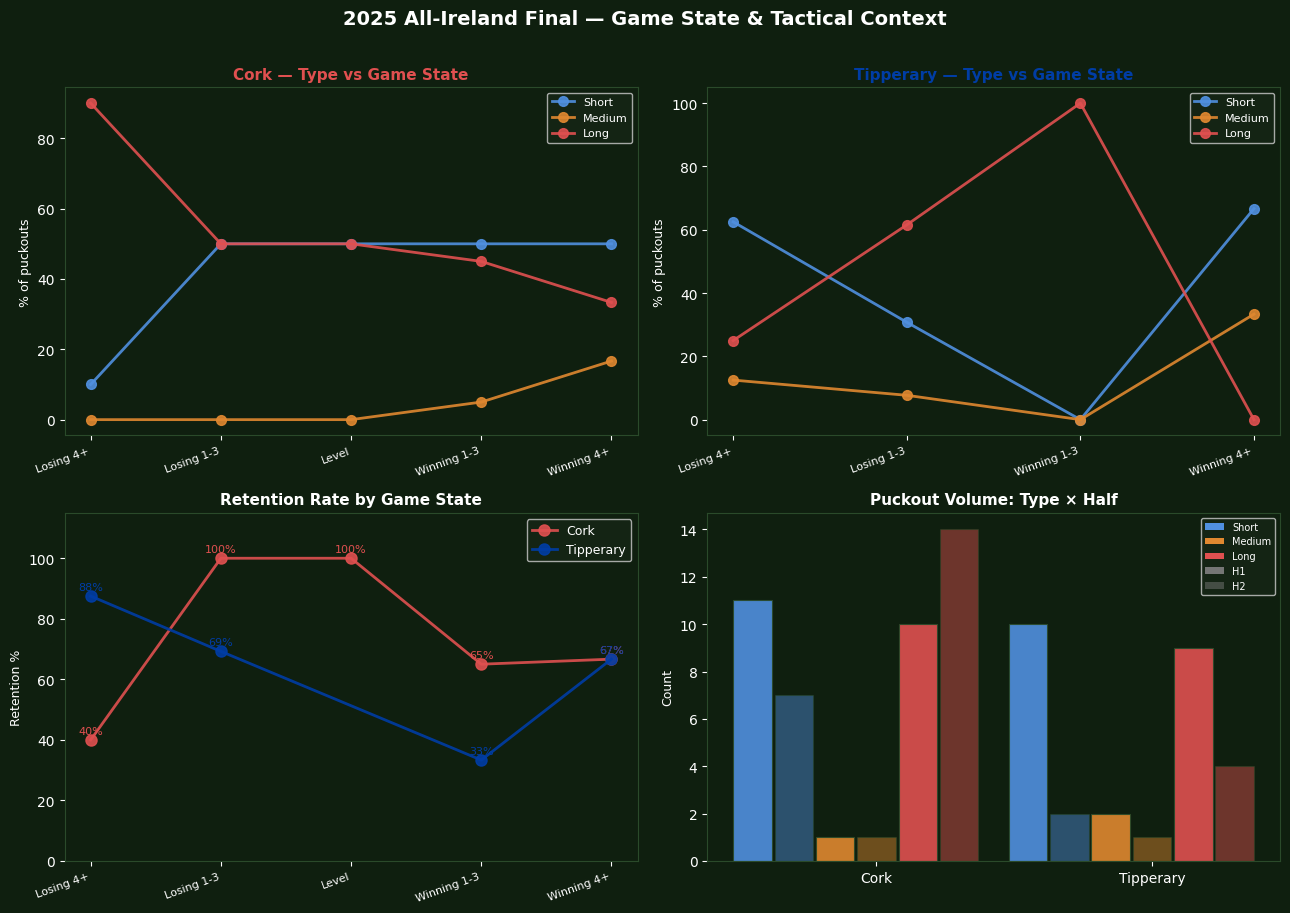


=== GAME STATE SUMMARY ===
                          puckouts retention long_pct short_pct
pucking_team game_state                                        
Cork         Level               4      100%      50%       50%
             Losing 1-3          4      100%      50%       50%
             Losing 4+          10       40%      90%       10%
             Winning 1-3        20       65%      45%       50%
             Winning 4+          6       67%      33%       50%
Tipperary    Level               1      100%       0%      100%
             Losing 1-3         13       69%      62%       31%
             Losing 4+           8       88%      25%       62%
             Winning 1-3         3       33%     100%        0%
             Winning 4+          3       67%       0%       67%


In [ ]:
# Q4: Game State Analysis

def bin_diff(d):
    if d<=-4:   return 'Losing 4+'
    elif d<=-1: return 'Losing 1-3'
    elif d==0:  return 'Level'
    elif d<=3:  return 'Winning 1-3'
    else:       return 'Winning 4+'

diff_order = ['Losing 4+','Losing 1-3','Level','Winning 1-3','Winning 4+']
po['game_state'] = po['score_diff'].apply(bin_diff)

fig, axes = plt.subplots(2,2,figsize=(13,9))
fig.patch.set_facecolor('#0f1f0f')

# P1 & P2: Type by game state per team
for col_i,team in enumerate(['Cork','Tipperary']):
    ax  = axes[0][col_i]
    col = C_COR if team=='Cork' else C_TIP
    sub = po[po['pucking_team']==team]
    for t,tc in zip(types,['#5090e0','#e08830','#e05050']):
        xs,ys = [],[]
        for gs_bin in diff_order:
            s = sub[sub['game_state']==gs_bin]
            if len(s)>=2:
                xs.append(gs_bin); ys.append(len(s[s['type']==t])/len(s)*100)
        ax.plot(xs,ys,'o-',color=tc,linewidth=2,markersize=7,label=t.title(),alpha=0.9)
    ax.set_title(f'{team} — Type vs Game State',color=col,fontsize=11,fontweight='bold')
    ax.set_ylabel('% of puckouts',color='white',fontsize=9)
    ax.legend(facecolor='#162616',labelcolor='white',fontsize=8)
    style_ax(ax)
    plt.setp(ax.xaxis.get_majorticklabels(),rotation=20,ha='right',color='white',fontsize=8)

# P3: Retention by game state
ax = axes[1][0]
for team,col in zip(teams,colors):
    sub = po[po['pucking_team']==team]
    xs,ys = [],[]
    for gs_bin in diff_order:
        s = sub[sub['game_state']==gs_bin]
        if len(s)>=2:
            xs.append(gs_bin); ys.append(s['retained_bool'].mean()*100)
    ax.plot(xs,ys,'o-',color=col,linewidth=2,markersize=8,label=team,alpha=0.9)
    for x_,y_ in zip(xs,ys):
        ax.text(x_,y_+2,f'{y_:.0f}%',ha='center',fontsize=8,color=col)
ax.set_title('Retention Rate by Game State',color='white',fontsize=11,fontweight='bold')
ax.set_ylabel('Retention %',color='white',fontsize=9)
ax.legend(facecolor='#162616',labelcolor='white',fontsize=9)
ax.set_ylim(0,115); style_ax(ax)
plt.setp(ax.xaxis.get_majorticklabels(),rotation=20,ha='right',color='white',fontsize=8)

# P4: Volume by half and type
ax = axes[1][1]
from matplotlib.patches import Patch as MPatch
for j,(t,tc) in enumerate(zip(types,['#5090e0','#e08830','#e05050'])):
    for k,half in enumerate([1,2]):
        sub    = po[po['half']==half]
        counts = [len(sub[(sub['pucking_team']==team)&(sub['type']==t)])
                  for team in teams]
        offset = (j*2+k)*0.15 - 0.45
        ax.bar(np.arange(2)+offset,counts,0.14,color=tc,
               alpha=0.9 if half==1 else 0.45,edgecolor='#2a4a2a',linewidth=0.8)
ax.set_xticks([0,1]); ax.set_xticklabels(teams,color='white',fontsize=10)
ax.set_ylabel('Count',color='white',fontsize=9)
ax.set_title('Puckout Volume: Type × Half',color='white',fontsize=11,fontweight='bold')
legend_elements = [
    MPatch(facecolor='#5090e0',label='Short'),
    MPatch(facecolor='#e08830',label='Medium'),
    MPatch(facecolor='#e05050',label='Long'),
    MPatch(facecolor='grey',alpha=0.9,label='H1'),
    MPatch(facecolor='grey',alpha=0.45,label='H2'),
]
ax.legend(handles=legend_elements,facecolor='#162616',
          labelcolor='white',fontsize=7,loc='upper right')
style_ax(ax)

plt.suptitle('2025 All-Ireland Final — Game State & Tactical Context',
             color='white',fontsize=14,fontweight='bold',y=1.01)
plt.tight_layout()
plt.savefig('q4_game_state.png',dpi=150,bbox_inches='tight',facecolor='#0f1f0f')
plt.show()

print("\n=== GAME STATE SUMMARY ===")
print(po.groupby(['pucking_team','game_state']).agg(
    puckouts=('id','count'),
    retention=('retained_bool',lambda x:f"{x.mean()*100:.0f}%"),
    long_pct=('type',lambda x:f"{(x=='long').mean()*100:.0f}%"),
    short_pct=('type',lambda x:f"{(x=='short').mean()*100:.0f}%"),
).to_string())

In [ ]:
# One-page match summary

cork    = po[po['pucking_team']=='Cork']
tipp    = po[po['pucking_team']=='Tipperary']
cork_fr = fr[fr['shooting_team']=='Cork']
tipp_fr = fr[fr['shooting_team']=='Tipperary']

W = 55
print("=" * W)
print("  2025 ALL-IRELAND FINAL — MATCH ANALYTICS SUMMARY")
print("  Cork vs Tipperary")
print("=" * W)

print(f"\n{'PUCKOUTS':─<{W}}")
print(f"{'Metric':<32} {'Cork':>10} {'Tipperary':>11}")
print("─" * W)
rows = [
    ("Total puckouts",          len(cork),                          len(tipp)),
    ("Retention rate",          f"{cork['retained_bool'].mean()*100:.0f}%",  f"{tipp['retained_bool'].mean()*100:.0f}%"),
    ("Short",                   (cork['type']=='short').sum(),       (tipp['type']=='short').sum()),
    ("Medium",                  (cork['type']=='medium').sum(),      (tipp['type']=='medium').sum()),
    ("Long",                    (cork['type']=='long').sum(),        (tipp['type']=='long').sum()),
    ("Short retention",         f"{cork[cork['type']=='short']['retained_bool'].mean()*100:.0f}%", f"{tipp[tipp['type']=='short']['retained_bool'].mean()*100:.0f}%"),
    ("Long retention",          f"{cork[cork['type']=='long']['retained_bool'].mean()*100:.0f}%",  f"{tipp[tipp['type']=='long']['retained_bool'].mean()*100:.0f}%"),
]
for label,c,t in rows:
    print(f"{label:<32} {str(c):>10} {str(t):>11}")

print(f"\n{'FREES & 65s':─<{W}}")
print(f"{'Metric':<32} {'Cork':>10} {'Tipperary':>11}")
print("─" * W)
fr_rows = [
    ("Total attempts",          len(cork_fr),                        len(tipp_fr)),
    ("Points scored",           (cork_fr['outcome']=='point').sum(), (tipp_fr['outcome']=='point').sum()),
    ("Goals scored",            (cork_fr['outcome']=='goal').sum(),  (tipp_fr['outcome']=='goal').sum()),
    ("Score conversion",        f"{cork_fr['scored'].mean()*100:.0f}%", f"{tipp_fr['scored'].mean()*100:.0f}%"),
    ("Wides",                   (cork_fr['outcome']=='wide').sum(),  (tipp_fr['outcome']=='wide').sum()),
    ("Possession retained",     (cork_fr['outcome']=='retained').sum(), (tipp_fr['outcome']=='retained').sum()),
]
for label,c,t in fr_rows:
    print(f"{label:<32} {str(c):>10} {str(t):>11}")
print("=" * W)

  2025 ALL-IRELAND FINAL — MATCH ANALYTICS SUMMARY
  Cork vs Tipperary

PUCKOUTS───────────────────────────────────────────────
Metric                                 Cork   Tipperary
───────────────────────────────────────────────────────
Total puckouts                           44          28
Retention rate                          66%         71%
Short                                    18          12
Medium                                    2           3
Long                                     24          13
Short retention                        100%        100%
Long retention                          42%         54%

FREES & 65s────────────────────────────────────────────
Metric                                 Cork   Tipperary
───────────────────────────────────────────────────────
Total attempts                           14          18
Points scored                             4          10
Goals scored                              0           1
Score conversion               